# Práctica - Clase 4: Aprendizaje Automático

## Actividad 2: Regresión Logística para predicción de Sistema Operativo

**Objetivo:** predecir qué sistema operativo usa un visitante de un sitio web (0 = Windows, 1 = Macintosh, 2 = Linux) a partir de 4 características tomadas de Google Analytics:

- `duracion`: duración de la visita en segundos
- `paginas`: cantidad de páginas vistas durante la sesión
- `acciones`: cantidad de acciones del usuario (clics, scroll, checkbox, sliders, etc.)
- `valor`: suma del valor de las acciones (cada acción tiene una valoración de importancia)

### 1. Importación de librerías
Se usa `pandas` y `numpy` para manejar los datos, `matplotlib` y `seaborn` para los gráficos y `scikit-learn` para el modelo.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model
from sklearn import model_selection
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")

### 2. Carga de Datos y Análisis Exploratorio (AED)
Buscamos valores atípicos (outliers), datos nulos y patrones visibles.

In [ ]:
# Cargar el dataset desde la carpeta de datos
df = pd.read_csv("../datos/usuarios_win_mac_lin.csv")
print("Filas y columnas:", df.shape)
display(df.head())

# Verificamos si existen datos nulos
print("Valores nulos por columna:")
display(df.isnull().sum())

# Estadisticas (minimos, maximos, promedios)
display(df.describe())

# Filas repetidas
print("Filas duplicadas:", df.duplicated().sum())

Filas y columnas: (170, 5)


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


Valores nulos por columna:


duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


Filas duplicadas: 16


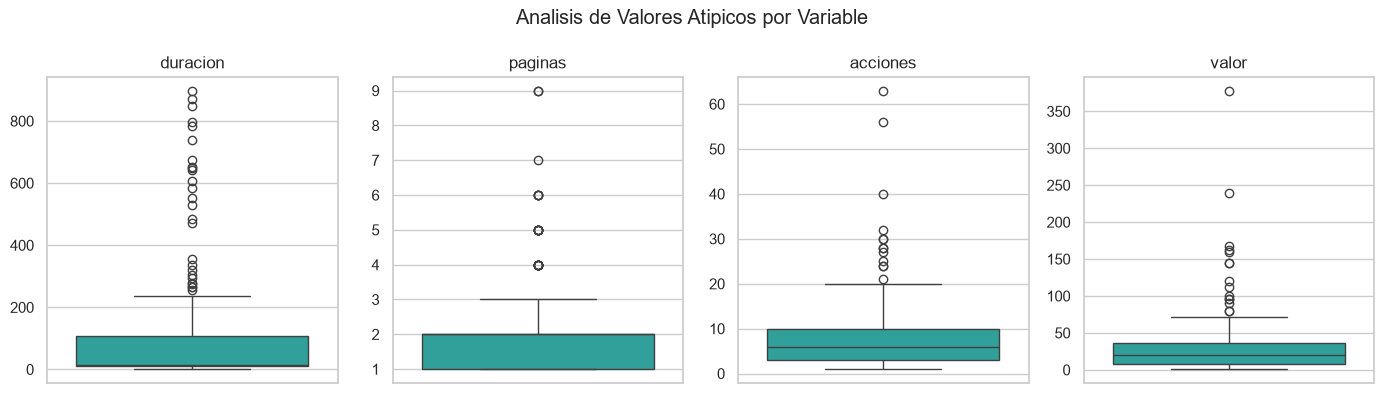

In [63]:
# Buscamos valores atipicos con un boxplot por variable.
# Cada variable tiene su propia escala, por eso se grafican en ejes separados.
variables = ["duracion", "paginas", "acciones", "valor"]
fig, ejes = plt.subplots(1, 4, figsize=(14, 4))
for eje, var in zip(ejes, variables):
    sns.boxplot(y=df[var], ax=eje, color="lightseagreen")
    eje.set_title(var)
    eje.set_ylabel("")
plt.suptitle("Analisis de Valores Atipicos por Variable")
plt.tight_layout()
plt.show()

In [64]:
# Respaldo estadistico de los boxplots
for var in variables:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = df[(df[var] < lim_inf) | (df[var] > lim_sup)]
    print(f"--- {var} ---")
    print(f"  Min: {df[var].min():.1f}  |  Q1: {q1:.1f}  |  Mediana: {df[var].median():.1f}  |  Q3: {q3:.1f}  |  Max: {df[var].max():.1f}")
    print(f"  IQR: {iqr:.1f}  |  Limite superior (Q3 + 1.5*IQR): {lim_sup:.1f}")
    print(f"  Outliers detectados: {len(outliers)} de {len(df)} ({len(outliers)/len(df)*100:.1f}%)")
    print()


--- duracion ---
  Min: 1.0  |  Q1: 11.0  |  Mediana: 13.0  |  Q3: 108.0  |  Max: 898.0
  IQR: 97.0  |  Limite superior (Q3 + 1.5*IQR): 253.5
  Outliers detectados: 26 de 170 (15.3%)

--- paginas ---
  Min: 1.0  |  Q1: 1.0  |  Mediana: 2.0  |  Q3: 2.0  |  Max: 9.0
  IQR: 1.0  |  Limite superior (Q3 + 1.5*IQR): 3.5
  Outliers detectados: 24 de 170 (14.1%)

--- acciones ---
  Min: 1.0  |  Q1: 3.0  |  Mediana: 6.0  |  Q3: 10.0  |  Max: 63.0
  IQR: 7.0  |  Limite superior (Q3 + 1.5*IQR): 20.5
  Outliers detectados: 13 de 170 (7.6%)

--- valor ---
  Min: 1.0  |  Q1: 8.0  |  Mediana: 20.0  |  Q3: 36.0  |  Max: 378.0
  IQR: 28.0  |  Limite superior (Q3 + 1.5*IQR): 78.0
  Outliers detectados: 15 de 170 (8.8%)



Las cuatro variables tienen una cola larga hacia arriba (visitas de hasta ~900 segundos, hasta 63 acciones y un valor de hasta 378).Como los valores son plausibles y coherentes entre sí (una visita con muchas acciones también tiene alto valor y más páginas), se asume que son visitas reales de usuarios muy activos y no errores, y lo conservamos ya que represenentan el ~15 % de los datos

clase
Windows      86
Linux        44
Macintosh    40
Name: count, dtype: int64


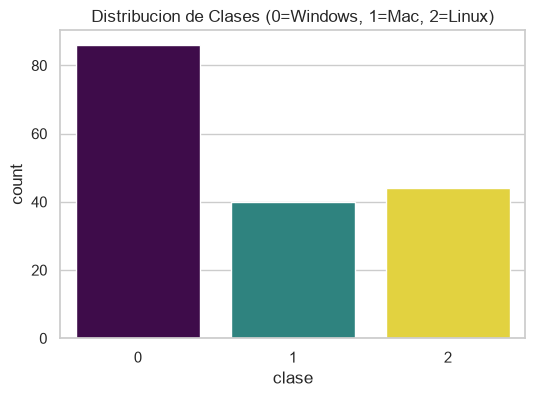

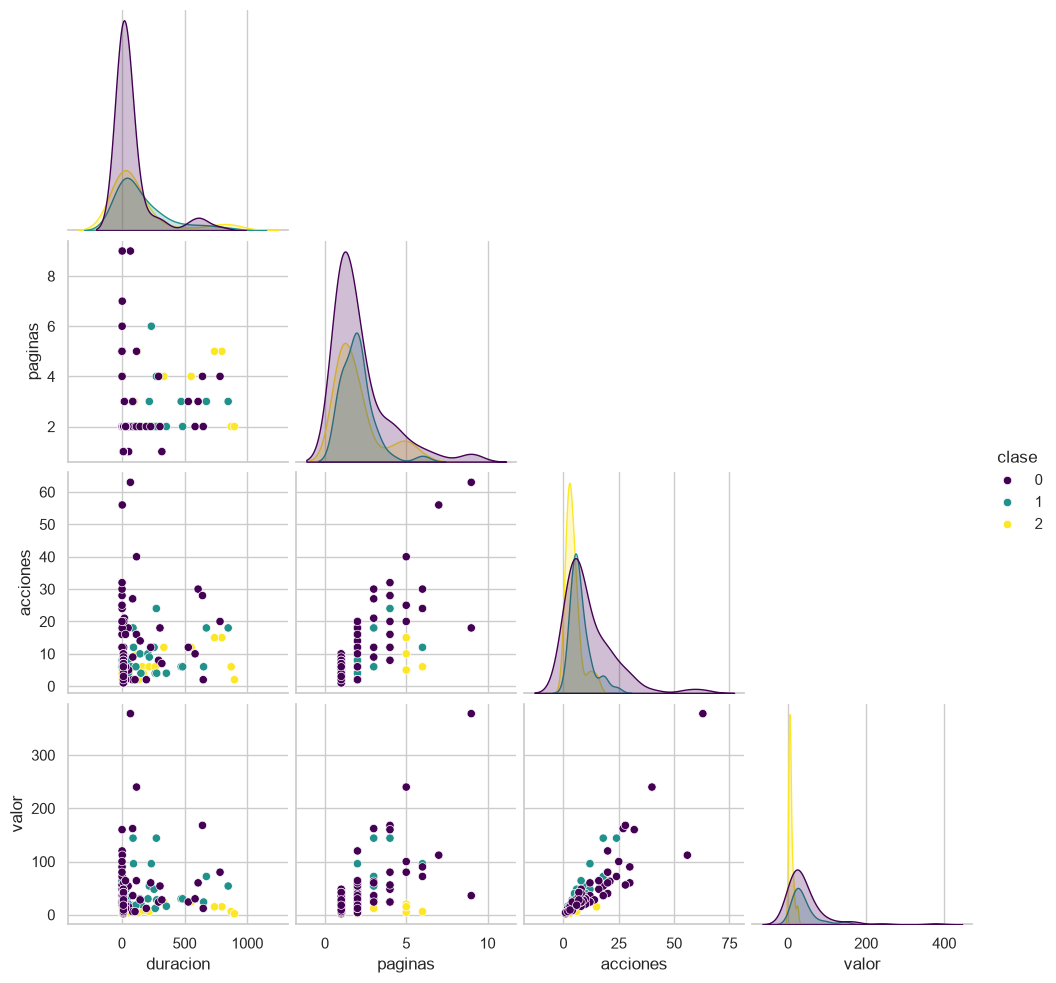

,duracion,paginas,acciones,valor
clase,,,,
0,13.0,1.0,7.5,27.5
1,50.0,2.0,6.0,30.0
2,12.0,1.0,3.0,4.5


In [65]:
# Distribucion de clases y relacion entre variables
etiquetas = {0: "Windows", 1: "Macintosh", 2: "Linux"}
print(df["clase"].map(etiquetas).value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="clase", hue="clase", palette="viridis", legend=False)
plt.title("Distribucion de Clases (0=Windows, 1=Mac, 2=Linux)")
plt.show()

sns.pairplot(df, hue="clase", palette="viridis", corner=True)
plt.show()

# Mediana de cada variable segun el sistema operativo
display(df.groupby("clase").median())

Como se puede ver, hay el doble de usuarios de Windows que de Mac o Linux (las clases estan desbalanceadas). En el pairplot los grupos se superponen bastante: no hay una separación nítida. Según las medianas, los usuarios de Linux tienen visitas con pocas acciones y poco valor. Los de Mac tienden a tener visitas más largas (mediana de 50 s contra ~13 s en Windows y Linux); y Windows tiene visitas cortas como Linux pero con más acciones y más valor, por lo que se mezcla con ambos. Esto anticipa que un modelo lineal no va a llegar a una precisión muy alta.

### 3. Preparación de los Datos y Modelado
Dividimos los datos en **Entrenamiento** (80 %) y **Prueba** (20 %).
 - Usamos `stratify=y` para que entrenamiento y prueba mantengan las mismas proporciones de Windows, Mac y Linux, ya que como se demostro, las clases están desbalanceadas.
  - Usamos `class_weight='balanced'` para que el modelo no favorezca a la clase mayoritaria (en este caso Windows) y preste atención a Mac y Linux.

In [66]:
# separamos las caracteristicas (X) y la etiqueta a predecir (y)
X = np.array(df.drop(["clase"], axis=1))
y = np.array(df["clase"])

# 80% para entrenar y 20% para evaluar (estratificado)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Regresion Logistica multiclase
clasificador = linear_model.LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced")
clasificador.fit(X_train, y_train)

print(f"Precision en datos de entrenamiento: {clasificador.score(X_train, y_train):.2f}")

Precision en datos de entrenamiento: 0.68


### 4. Evaluación de la Clasificación
Le pasamos al modelo los datos de prueba (`X_test`) y comparamos sus predicciones con la realidad usando el reporte de clasificación y la matriz de confusión (la diagonal son los aciertos).

Precision general en datos de prueba: 0.76

Reporte de Clasificacion Detallado:
              precision    recall  f1-score   support

     Windows       0.91      0.59      0.71        17
   Macintosh       0.78      0.88      0.82         8
       Linux       0.64      1.00      0.78         9

    accuracy                           0.76        34
   macro avg       0.78      0.82      0.77        34
weighted avg       0.81      0.76      0.76        34



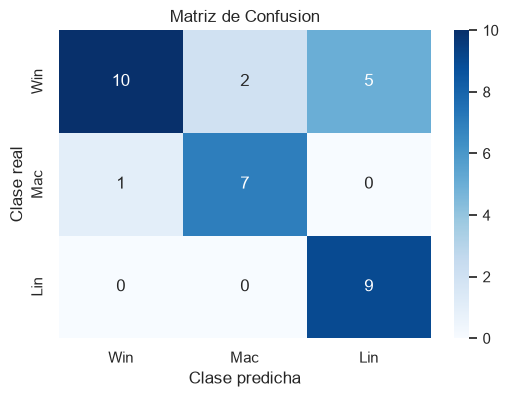

In [67]:
prediccion = clasificador.predict(X_test)
print(f"Precision general en datos de prueba: {accuracy_score(y_test, prediccion):.2f}\n")

print("Reporte de Clasificacion Detallado:")
print(classification_report(y_test, prediccion, target_names=["Windows", "Macintosh", "Linux"]))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, prediccion), annot=True, cmap="Blues", fmt="d",
            xticklabels=["Win", "Mac", "Lin"], yticklabels=["Win", "Mac", "Lin"])
plt.title("Matriz de Confusion")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.show()

Validación cruzada: con solo 34 datos de prueba, un único resultado puede ser engañoso (un acierto más o menos cambia varios puntos). Por eso repetimos la evaluación con 5 divisiones distintas y promediamos.

In [68]:
skf = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
puntajes = model_selection.cross_val_score(clasificador, X, y, cv=skf)
print("Precision en cada particion:", np.round(puntajes, 2))
print(f"Precision promedio: {puntajes.mean():.2f} (+/- {puntajes.std():.2f})")

Precision en cada particion: [0.68 0.65 0.79 0.71 0.74]
Precision promedio: 0.71 (+/- 0.05)


#### ¿Ayuda escalar las variables?
`duracion` llega a 898 mientras que `paginas` llega a 9. Como la regresión logística puede ser sensible a las escalas, se prueba estandarizar (`StandardScaler`) y comparamos con el modelo anterior usando la misma validación cruzada.

In [69]:
modelo_escalado = make_pipeline(
    StandardScaler(),
    linear_model.LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced")
)
cv_escalado = model_selection.cross_val_score(modelo_escalado, X, y, cv=skf)
print(f"Sin escalar: {puntajes.mean():.2f} (+/- {puntajes.std():.2f})")
print(f"Escalado:    {cv_escalado.mean():.2f} (+/- {cv_escalado.std():.2f})")

Sin escalar: 0.71 (+/- 0.05)
Escalado:    0.68 (+/- 0.07)


Escalar no mejora el resultado (hasta incluso rinde un poco peor), así que mantenemos el modelo sin escalar. La limitación no está en la escala de las variables, sino en que las clases se superponen

### 5. Visualización de Fronteras de Decisión
Usamos pcolormesh para dibujar las "áreas" en las que el modelo decide si alguien usa Windows, Mac o Linux.
Debe de tener solo dos ejes, así que entrenamos un modelo auxiliar con dos variables (`duracion` y `acciones`) para poder ver las fronteras. 

>**Nota: Solo en este paso se utiliza esta simplificación, el modelo principal usa las 4 variables**

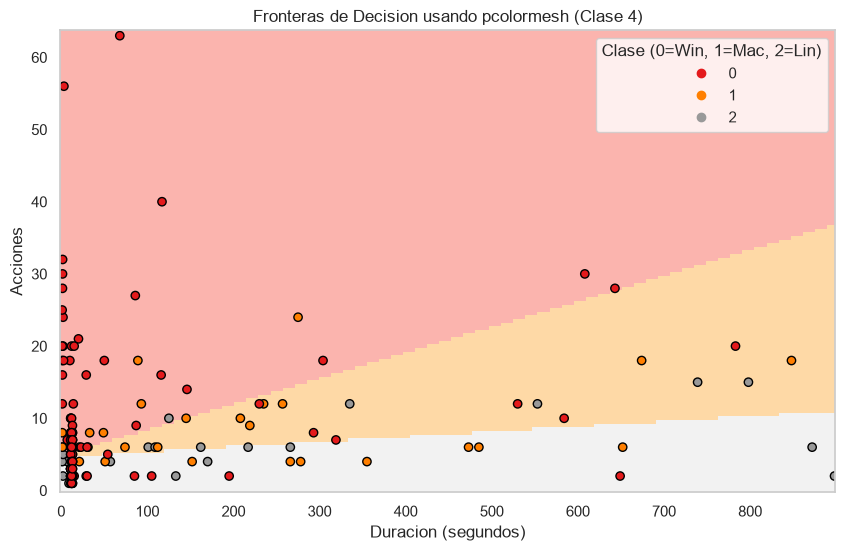

Precision del modelo 2D: 0.56


In [ ]:
# Filtramos solo 2 variables
X_2d = df[["duracion", "acciones"]].values
y_2d = df["clase"].values

# ** Modelo auxiliar **
clasificador_2d = linear_model.LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced")
clasificador_2d.fit(X_2d, y_2d)

# Rango de visualizacion (margen de 1 unidad)
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

# Malla de puntos (cada eje tiene una escala distinta, por eso usa pasos distintos)
valor_x, valor_y = np.meshgrid(np.arange(x_min, x_max, 2.0), np.arange(y_min, y_max, 0.5))

# Predecimos la clase de cada punto de la malla (ravel y np.c_)
malla_de_puntos = clasificador_2d.predict(np.c_[valor_x.ravel(), valor_y.ravel()])
malla_de_puntos = malla_de_puntos.reshape(valor_x.shape)

# Se dibnuja todo
plt.figure(figsize=(10, 6))
plt.pcolormesh(valor_x, valor_y, malla_de_puntos, cmap=plt.cm.Pastel1, shading="auto")
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, edgecolors="black", cmap=plt.cm.Set1)
plt.title("Fronteras de Decision usando pcolormesh (Clase 4)")
plt.xlabel("Duracion (segundos)")
plt.ylabel("Acciones")
plt.legend(*scatter.legend_elements(), title="Clase (0=Win, 1=Mac, 2=Lin)")
plt.show()

print(f"Precision del modelo 2D: {clasificador_2d.score(X_2d, y_2d):.2f}")

### 6.Predicción de un Usuario Nuevo(Caso de Uso)
en un escenario donde un usuario nuevo acaba de finalizar su visita: ¿Qué sistema operativo predice el modelo?

In [71]:
# Datos del usuario nuevo: [duracion, paginas, acciones, valor]
nuevo_usuario = np.array([[45, 3, 6, 9]])

prediccion_en_vivo = clasificador.predict(nuevo_usuario)
probabilidades = clasificador.predict_proba(nuevo_usuario)[0]

sistemas_operativos = {0: "Windows", 1: "Macintosh", 2: "Linux"}
resultado = sistemas_operativos[prediccion_en_vivo[0]]

print("-" * 44)
print("         PREDICCION DE NUEVO USUARIO")
print("-" * 44)
print("Datos ingresados:")
print("  Duracion: 45s | Paginas: 3 | Acciones: 6 | Valor: 9")
print("-" * 44)
print(f"Prediccion del modelo: {resultado}")
print("Probabilidad por clase:")
for clase, prob in zip(clasificador.classes_, probabilidades):
    print(f"  {sistemas_operativos[clase]:<10} {prob:.1%}")
print("-" * 44)

--------------------------------------------
         PREDICCION DE NUEVO USUARIO
--------------------------------------------
Datos ingresados:
  Duracion: 45s | Paginas: 3 | Acciones: 6 | Valor: 9
--------------------------------------------
Prediccion del modelo: Linux
Probabilidad por clase:
  Windows    0.2%
  Macintosh  0.1%
  Linux      99.7%
--------------------------------------------


## Conclusiones
- El modelo de regresión logística con las 4 variables acierta alrededor del 71 % en validación cruzada (76 % en la partición de prueba), muy por encima de predecir siempre Windows (86 de 170 usuarios, ~51 %).
- Linux tiene recall 1.0 (no se escapa ningún usuario de Linux), pero con precisión de solo 0.64, porque el modelo le asigna usuarios de otros sistemas. **Windows** es la clase peor recuperada (recall ~0.6): muchos usuarios de Windows se clasifican como Mac o Linux.
- El modelo 2D de la sección 5 es solo ilustrativo para aplicar la teoria vista en la clase (usa 2 de las 4 variables y su precisión es mucho menor).
- Escalar las variables no mejoró el modelo. El límite está en que las clases se superponen y las variables disponibles no alcanzan para separarlas con una frontera lineal.